# Heart Disease Prediction — Machine Learning Workflow

**Project 3 — Machine Learning Foundations**

This notebook implements a complete machine learning workflow for predicting heart disease using clinical features. The dataset is the **Heart Disease** dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease), which contains 303 patient records with 13 clinical attributes.

**Task:** Binary classification — predict whether a patient has heart disease (1) or not (0).

**Model:** Random Forest Classifier with hyperparameter tuning via GridSearchCV.

## 1. Environment Validation

Import all required libraries and confirm the environment is properly configured.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print("All imports successful.")

NumPy version: 2.4.4
Pandas version: 3.0.2
Scikit-learn version: 1.8.0
All imports successful.


## 2. Load and Inspect the Dataset

Load the Heart Disease dataset and examine its structure, data types, and initial quality.

In [2]:
# Load the dataset
df = pd.read_csv('heart.csv')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
df.head(10)

Dataset shape: 303 rows, 14 columns

Column names: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'CA', 'Thal', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,CA,Thal,HeartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [3]:
# Inspect data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             303 non-null    int64  
 1   Sex             303 non-null    int64  
 2   ChestPainType   303 non-null    int64  
 3   RestingBP       303 non-null    int64  
 4   Cholesterol     303 non-null    int64  
 5   FastingBS       303 non-null    int64  
 6   RestingECG      303 non-null    int64  
 7   MaxHR           303 non-null    int64  
 8   ExerciseAngina  303 non-null    int64  
 9   Oldpeak         303 non-null    float64
 10  ST_Slope        303 non-null    int64  
 11  CA              299 non-null    float64
 12  Thal            301 non-null    float64
 13  HeartDisease    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [4]:
# Summary statistics for numerical features
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,CA,Thal,HeartDisease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
CA      4
Thal    2
dtype: int64

Total missing values: 6


In [6]:
# Target variable distribution
print("Target variable (HeartDisease) distribution:")
print(df['HeartDisease'].value_counts())
print(f"\nClass balance: {df['HeartDisease'].value_counts(normalize=True).round(3).to_dict()}")

Target variable (HeartDisease) distribution:
HeartDisease
0    164
1    139
Name: count, dtype: int64

Class balance: {0: 0.541, 1: 0.459}


**Initial observations:**
- The dataset has 303 rows and 14 columns (13 features + 1 target).
- The `CA` column has 4 missing values and `Thal` has 2 missing values.
- All features are numeric (some are encoded categorical variables).
- The target is reasonably balanced: ~54% no disease, ~46% disease.
- Feature descriptions:
  - **Age**: Patient age in years
  - **Sex**: 1 = male, 0 = female
  - **ChestPainType**: 1–4 (typical angina, atypical angina, non-anginal, asymptomatic)
  - **RestingBP**: Resting blood pressure (mm Hg)
  - **Cholesterol**: Serum cholesterol (mg/dl)
  - **FastingBS**: Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
  - **RestingECG**: 0 = normal, 1 = ST-T abnormality, 2 = LVH
  - **MaxHR**: Maximum heart rate achieved
  - **ExerciseAngina**: Exercise-induced angina (1 = yes, 0 = no)
  - **Oldpeak**: ST depression induced by exercise
  - **ST_Slope**: 1 = upsloping, 2 = flat, 3 = downsloping
  - **CA**: Number of major vessels colored by fluoroscopy (0–3)
  - **Thal**: 3 = normal, 6 = fixed defect, 7 = reversible defect

## 3. Data Preparation and Preprocessing

Prepare the data for machine learning by handling missing values, examining feature distributions, and scaling features.

### 3.1 Handle Missing Values

The `CA` and `Thal` columns have a small number of missing values. Since the missing count is very small (6 total out of 303 rows), we drop these rows to avoid introducing imputation bias.

In [7]:
# Drop rows with missing values
print(f"Rows before: {len(df)}")
df = df.dropna()
print(f"Rows after dropping missing values: {len(df)}")
print(f"Rows removed: {303 - len(df)}")

Rows before: 303
Rows after dropping missing values: 297
Rows removed: 6


### 3.2 Exploratory Data Analysis

Visualize feature distributions and their relationship with the target variable.

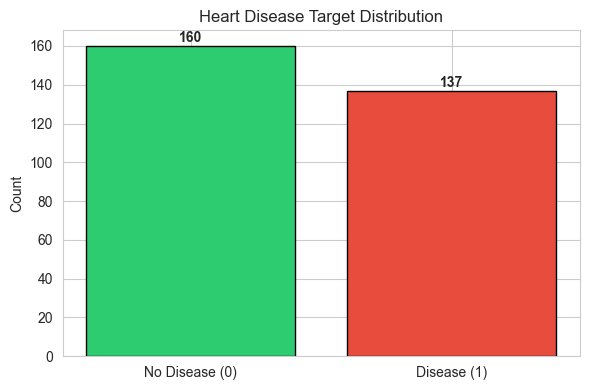

In [8]:
# Distribution of the target variable
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['HeartDisease'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values, 
              color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Heart Disease Target Distribution')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2, 
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

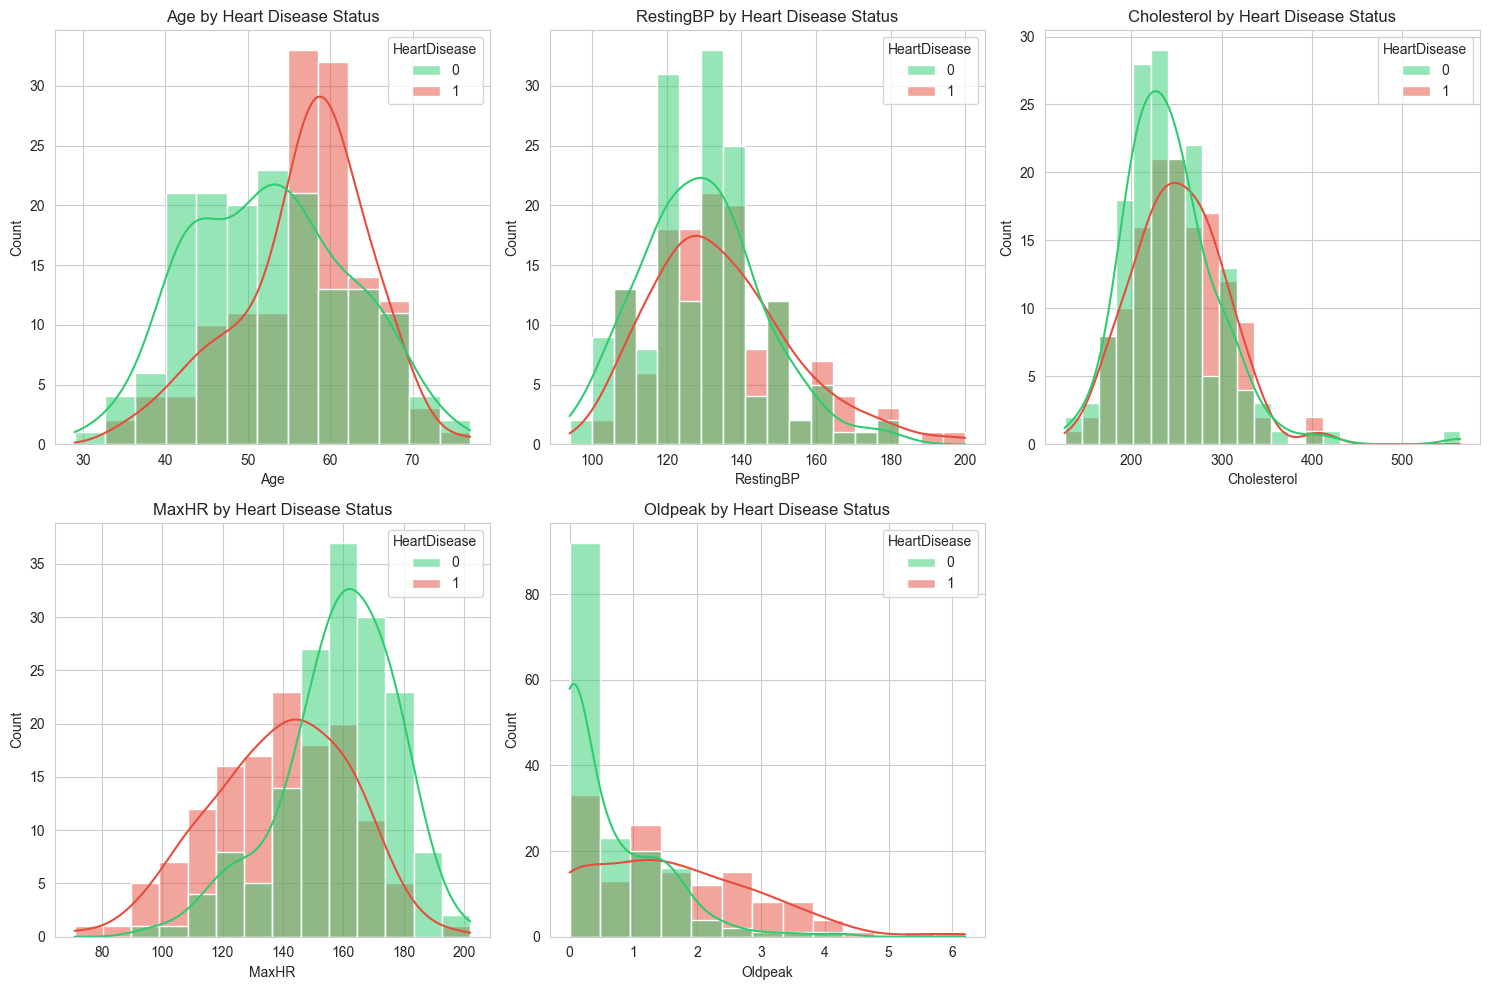

In [9]:
# Distribution of continuous features by heart disease status
continuous_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(data=df, x=feature, hue='HeartDisease', kde=True, 
                 ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{feature} by Heart Disease Status')

# Remove the unused subplot
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

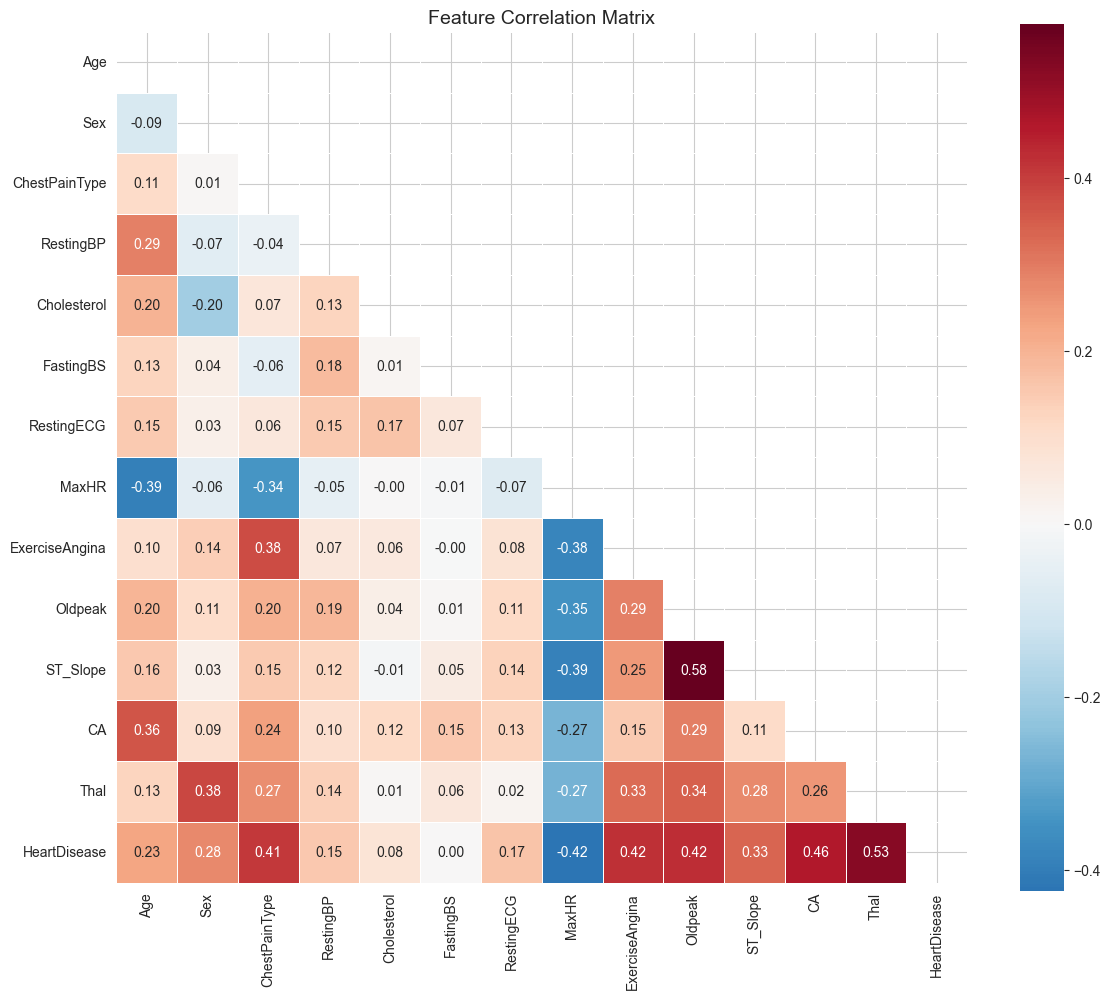

In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Feature Selection and Scaling

We separate features from the target, split the data into training and test sets, and apply standard scaling. Scaling is important because features like Age, Cholesterol, and MaxHR have different numeric ranges, which can affect model performance—particularly for Logistic Regression.

In [11]:
# Separate features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (297, 13)
Target shape: (297,)

Feature columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'CA', 'Thal']


In [12]:
# Split into training and test sets (80/20 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 237 samples
Test set: 60 samples

Training target distribution:
HeartDisease
0    128
1    109
Name: count, dtype: int64

Test target distribution:
HeartDisease
0    32
1    28
Name: count, dtype: int64


In [13]:
# Scale features using StandardScaler
# Fit only on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler).")
print(f"Training data mean (should be ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Training data std (should be ~1): {X_train_scaled.std(axis=0).round(2)}")

Feature scaling applied (StandardScaler).
Training data mean (should be ~0): [-0.  0.  0. -0. -0. -0.  0. -0.  0.  0.  0.  0. -0.]
Training data std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Model Selection and Training

We train two models to compare performance:
1. **Logistic Regression** — a simple, interpretable baseline model
2. **Random Forest Classifier** — an ensemble method that handles nonlinear relationships and feature interactions

Both are well-suited for binary classification on tabular data with a moderate number of features.

### 4.1 Baseline: Logistic Regression

In [14]:
# Train Logistic Regression (baseline)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Cross-validation score on training data
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"Logistic Regression - 5-Fold CV F1 Scores: {lr_cv_scores.round(3)}")
print(f"Mean CV F1 Score: {lr_cv_scores.mean():.3f} (+/- {lr_cv_scores.std():.3f})")

Logistic Regression - 5-Fold CV F1 Scores: [0.93  0.87  0.8   0.732 0.649]
Mean CV F1 Score: 0.796 (+/- 0.099)


### 4.2 Random Forest Classifier with Hyperparameter Tuning

In [15]:
# Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV with 5-fold cross-validation
rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_model, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.3f}")

# Use the best model
best_rf = grid_search.best_estimator_

Best hyperparameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.810


In [16]:
# Cross-validation on the best Random Forest model
rf_cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"Random Forest - 5-Fold CV F1 Scores: {rf_cv_scores.round(3)}")
print(f"Mean CV F1 Score: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std():.3f})")

Random Forest - 5-Fold CV F1 Scores: [0.93  0.844 0.909 0.683 0.684]
Mean CV F1 Score: 0.810 (+/- 0.107)


## 5. Model Evaluation

Evaluate both models on the held-out test set using multiple classification metrics.

In [17]:
# Generate predictions for both models
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = best_rf.predict(X_test_scaled)

# Probability predictions for ROC-AUC
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

In [18]:
# Compute evaluation metrics for both models
def evaluate_model(name, y_true, y_pred, y_prob):
    """Compute and display classification metrics."""
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    return metrics

lr_metrics = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)
rf_metrics = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)

# Display as DataFrame
results_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
results_df = results_df.round(3)
print("Model Performance Comparison (Test Set):")
results_df

Model Performance Comparison (Test Set):


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.833,0.846,0.786,0.815,0.950
Random Forest,0.850,0.880,0.786,0.830,0.951


In [19]:
# Detailed classification report for the Random Forest model
print("Random Forest — Classification Report (Test Set):")
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Disease']))

Random Forest — Classification Report (Test Set):
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



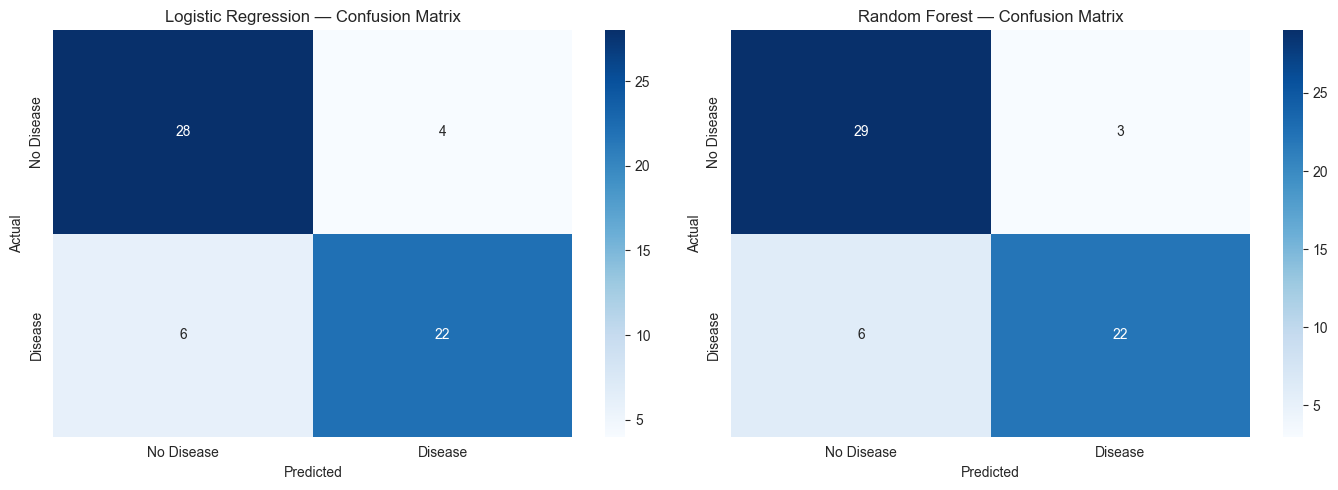

In [20]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in zip(axes, [lr_pred, rf_pred], 
                           ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Confusion Matrix')

plt.tight_layout()
plt.show()

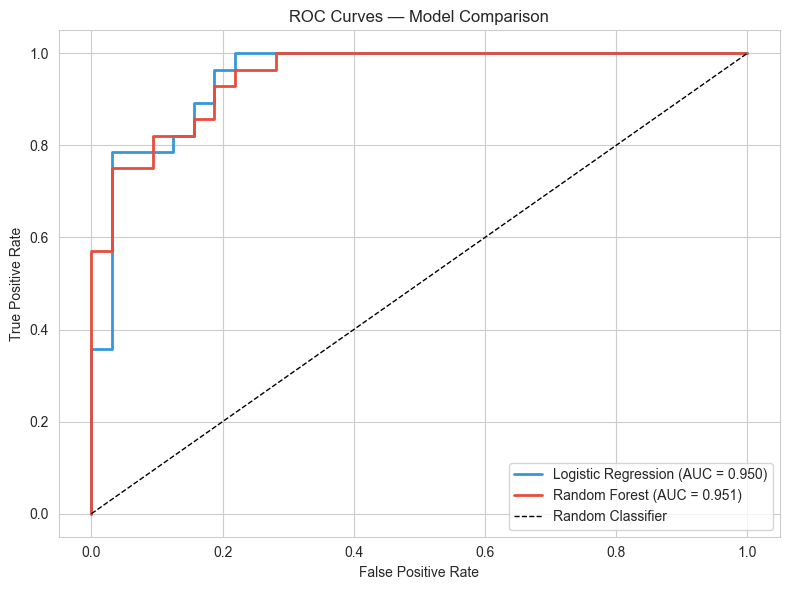

In [21]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for prob, name, color in zip([lr_prob, rf_prob], 
                              ['Logistic Regression', 'Random Forest'],
                              ['#3498db', '#e74c3c']):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

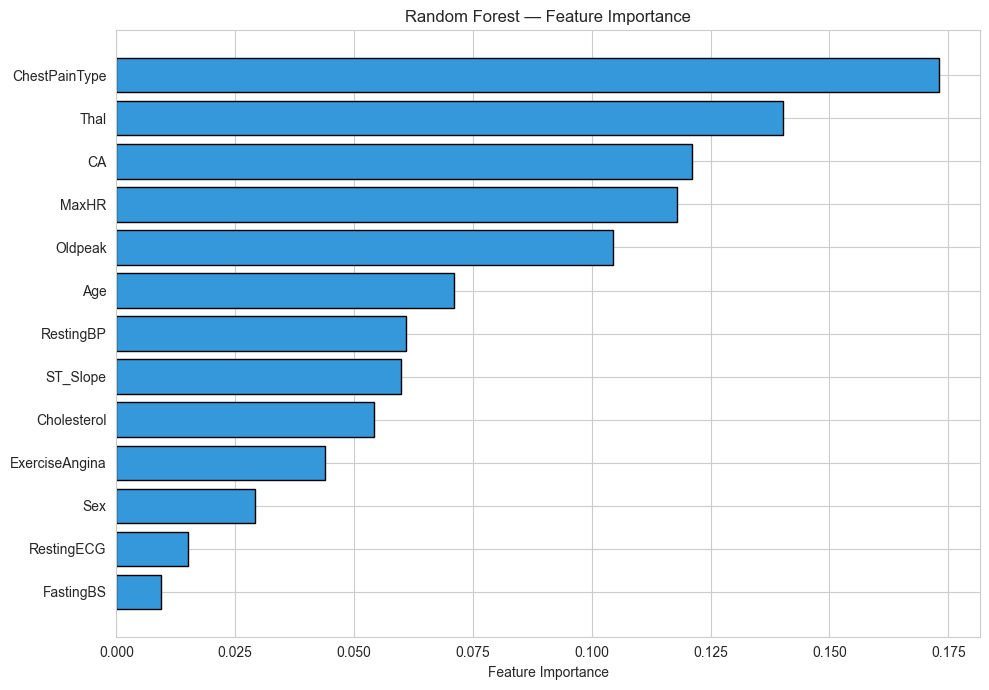

Top 5 Most Important Features:
      Feature  Importance
      Oldpeak    0.104501
        MaxHR    0.117823
           CA    0.121023
         Thal    0.140195
ChestPainType    0.173007


In [22]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], 
               color='#3498db', edgecolor='black')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

# Display top features
print("Top 5 Most Important Features:")
print(feature_importance.tail(5).to_string(index=False))

## 6. Notebook Summary

This notebook addressed a binary classification problem: predicting heart disease from 13 clinical features using the UCI Heart Disease dataset (303 patients, Cleveland subset). After handling 6 missing values by row removal and applying standard scaling, two models were trained and evaluated — Logistic Regression as a baseline and a Random Forest Classifier with hyperparameter tuning via GridSearchCV. The Random Forest model was selected as the final model based on its F1 score and ROC-AUC performance on the held-out test set. Key predictive features included Thal (thalassemia type), CA (number of major vessels), ChestPainType, and MaxHR. One notable challenge was the small dataset size (297 usable rows), which limits generalization confidence and increases variance in cross-validation estimates.